In [8]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
from cns.process.breakpoints import make_breaks
from cns.data_utils import load_COSMIC
import random
import numpy as np

cosmic_genes = load_COSMIC()
cosmic_genes.head()

_, start, end = make_breaks("arms")["chr3"]
gene_start, gene_end = cosmic_genes.query("gene == 'SOX2'")[["start", "end"]].values.tolist()[0]

In [86]:
# Initialize a list to store the ranges
ranges = []

reps = 50

# Repeat until 8 ranges are sampled
while len(ranges) < 5 * reps:
    # Generate a random range
    if random.random() < 0.66:
        rand_start = random.randint(start, end)
    else:
        rand_start = start
    if random.random() < 0.5:
        rand_end = random.randint(rand_start, end)
    else:
        rand_end = end

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges.append((rand_start, rand_end))

In [87]:
breaks = np.array(ranges).flatten()
breaks.sort()
split_ranges = []

for r_start, r_end in ranges:
    current_start = r_start

    for brk in breaks:
        if r_start < brk < r_end:
            split_ranges.append((current_start, brk))
            current_start = brk

    split_ranges.append((current_start, r_end))

In [88]:
import pandas as pd

# Count the occurrences of each pair
counts = pd.Series(split_ranges).value_counts().reset_index()

# Rename the columns
counts.columns = ['range', 'CN']

# Split the range into start and end
counts[['start', 'end']] = pd.DataFrame(counts['range'].tolist(), index=counts.index)

# Drop the 'range' column
counts = counts.drop('range', axis=1)

# Reorder the columns
counts = counts[['start', 'end', 'CN']].sort_values(by=['start'], ignore_index=True)
counts["CN"] = counts["CN"] / reps + 2
counts.head()

,start,end,CN
0,91000000,91618494,3.44
1,91618494,93927218,3.46
2,93927218,95419642,3.48
3,95419642,95472396,3.50
4,95472396,95701024,3.52


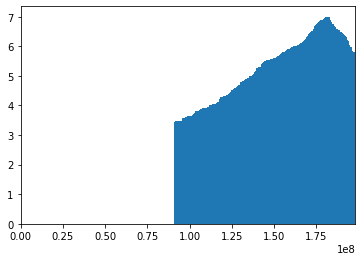

In [89]:
import matplotlib.pyplot as plt

# Calculate the widths of the bars
widths = counts['end'] - counts['start']

# Create a bar plot
plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))

# Display the plot
plt.show()

In [76]:
from cns.data_utils import load_merged_samples, load_merged_cns, get_cns_for_type

samples = load_merged_samples().query("type == 'LUSC'")
cns = load_merged_cns(samples)
data_chrom3 = cns.query("chrom == 'chr3'")

In [17]:
from cns.process.breakpoints import get_breaks
data_breaks = get_breaks(data_chrom3)

In [18]:
from cns.process.binning import bin_by_breaks

binned_data = bin_by_breaks(data_chrom3, data_breaks, print_progress=True)

C:\Users\adams\Ubuntu\cnsistent\cns\process\binning.py:98: RuntimeWarning: invalid value encountered in cast
  sel_array = np.array(seg_cns, dtype=np.uint32)
C:\Users\adams\Ubuntu\cnsistent\cns\process\binning.py:98: RuntimeWarning: invalid value encountered in cast
  sel_array = np.array(seg_cns, dtype=np.uint32)


Binning chr (853/853)


In [19]:
from cns.process.binning import group_bins, add_cns_loc

groups = group_bins(add_cns_loc(binned_data))

In [20]:
groups

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn,nMajor_cn,nMinor_cn
0,492498232,chr3,0,96476,48238,96476,1.766010,0.189655,1.955665,0.0,0.0
1,492611887,chr3,96476,227311,161893,130835,1.770936,0.189655,1.960591,0.0,0.0
2,492708893,chr3,227311,290487,258899,63176,1.773399,0.189655,1.963054,0.0,0.0
3,492742812,chr3,290487,295149,292818,4662,1.775862,0.189655,1.965517,0.0,0.0
4,492790654,chr3,295149,386172,340660,91023,1.780788,0.189655,1.970443,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3945,689677678,chr3,197222610,197232759,197227684,10149,4.110837,1.625616,5.736453,0.0,0.0
3946,689735041,chr3,197232759,197337336,197285047,104577,4.064039,1.623153,5.687192,0.0,0.0
3947,689832665,chr3,197337336,197428006,197382671,90670,4.064039,1.623153,5.687192,0.0,0.0
3948,689939258,chr3,197428006,197550523,197489264,122517,4.064039,1.623153,5.687192,0.0,0.0


(0.0, 198022430.0)

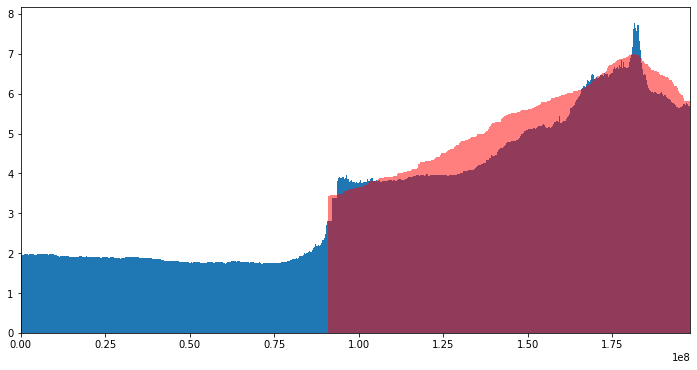

In [90]:
# bar plot groups 
fig, ax = plt.subplots(figsize=(12, 6))

# Create a bar plot
plt.bar(x=groups['start'], height=groups['total_cn'], width=(groups['end'] - groups['start']), align='edge')

plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge', alpha=0.5, color='red')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))
